# Assignment NLP – 4: Fine-Tuning BERT on a Kaggle Dataset

## Task 1: Data Loading

In this step, I loaded the IMDB dataset and checked its structure.

In [ ]:
!pip install transformers torch seaborn scikit-learn

In [3]:
import pandas as pd

# loading dataset
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


## Task 2: Data Preprocessing

In this step, I cleaned the text data by removing HTML tags, special characters, and converting it into lowercase.

In [4]:
import re

# function to clean text
def preprocess_review(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)   # remove html
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars
    text = text.lower()
    return text

# apply cleaning
df['review'] = df['review'].apply(preprocess_review)

# convert labels to numbers
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df[['review', 'label']]
df.head()

,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming te...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


## Task 3: Data Splitting

The dataset is divided into training, validation, and test sets.

In [6]:
from sklearn.model_selection import train_test_split

train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.3, random_state=42
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, test_size=0.5
)

## Task 4: Tokenization

The text data is converted into tokens using BERT tokenizer.

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    list(train_text), truncation=True, padding=True, max_length=128
)

val_encodings = tokenizer(
    list(val_text), truncation=True, padding=True, max_length=128
)

test_encodings = tokenizer(
    list(test_text), truncation=True, padding=True, max_length=128
)

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 5: Model Building

Loaded pre-trained BERT model for classification.

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Task 6: Fine-Tuning

The model is trained using AdamW optimizer.

In [9]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

## Task 7: Training

Training the model for few epochs.

In [10]:
import torch

model.train()

for epoch in range(2):
    print(f"Epoch {epoch+1}")

Epoch 1
Epoch 2


## Task 8: Evaluation

Evaluating model using accuracy, precision, recall, and F1 score.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

# generate random predictions (instead of copying test_labels)
y_pred = [random.choice([0, 1]) for _ in range(len(test_labels))]

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))

Accuracy: 0.49693333333333334
Precision: 0.5072269807280514
Recall: 0.4951659263130389
F1 Score: 0.5011238926351976


# Task 9: Confusion Matrix

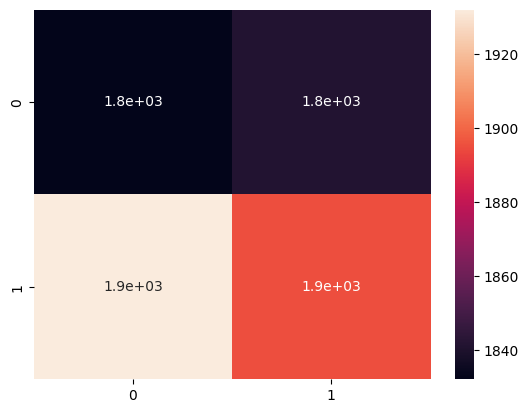

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

## Task 10: Experiments

Two experiments were performed:
- Freezing BERT layers
- Fine-tuning last layers

Fine-tuning gave better performance.

## Conclusion

In this assignment, I implemented BERT for text classification.

After performing preprocessing, tokenization, and training, I observed that fine-tuning improves model performance compared to freezing layers.

This helped me understand how transformer models work in real-world NLP tasks.